# Model Definition and Training

Defines the GCN architecture and trains two classifiers:

Saves interaction_model.pt and bio_model.pt to the working directory.




In [ ]:
from pathlib import Path
import networkx as nx
import pandas as pd
import numpy as np

FOLDER = Path('./asnr datasets')
assert FOLDER.exists(), f"Dataset folder not found: {FOLDER}"

asnr_graphs: dict[str, nx.Graph] = {}
for fp in FOLDER.glob('*.graphml'):
    asnr_graphs[fp.stem + '.graphml'] = nx.read_graphml(fp)

info_frame = pd.read_csv(FOLDER / 'Network_summary_masterfile.csv')

selected_classes = ['Mammalia', 'Insecta', 'Aves']
selected_interactions = [
    'physical_contact',
    'social_projection_bipartite',
    'spatial_proximity',
    'grooming',
    'dominance',
    'FE_mating',
]

filtered_df = (
    info_frame[
        info_frame['interaction_type'].isin(selected_interactions) &
        info_frame['class'].isin(selected_classes) &
        (info_frame['nodes'] > 5) &
        pd.notna(info_frame['avg.edge.strength'])
    ]
    .copy()
    .rename(columns={'class': 'network_class'})
    .reset_index(drop=True)
)

interaction_mapping = {c: i for i, c in enumerate(selected_interactions)}
bio_class_mapping   = {c: i for i, c in enumerate(selected_classes)}
filtered_df['interaction_map'] = filtered_df['interaction_type'].map(interaction_mapping)

bio_inv         = {v: k for k, v in bio_class_mapping.items()}
interaction_inv = {v: k for k, v in interaction_mapping.items()}
bio_names       = [bio_inv[i] for i in sorted(bio_inv)]

print(f"Loaded {len(asnr_graphs)} graphs | Filtered: {len(filtered_df)}")


Loaded 1197 graphs | Filtered: 924


In [ ]:
import copy, random, torch
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data

def build_dataset(graphs_dict, df_subset):
    dataset = []
    for _, row in df_subset.iterrows():
        key = row['Network_ID']
        if key not in graphs_dict:
            continue
        G = graphs_dict[key]
        G = G.to_undirected() if G.is_directed() else G
        node_mapping = {node: i for i, node in enumerate(G.nodes())}
        clustering   = nx.clustering(G)
        x = torch.tensor(
            [[G.degree(n), clustering[n]] for n in G.nodes()], dtype=torch.float)
        edges = []
        for u, v in G.edges():
            edges += [[node_mapping[u], node_mapping[v]],
                      [node_mapping[v], node_mapping[u]]]
        if not edges:
            continue
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        data            = Data(x=x, edge_index=edge_index,
                               y=torch.tensor([row['interaction_map']], dtype=torch.long))
        data.bio_class  = torch.tensor(
            [bio_class_mapping.get(row['network_class'], -1)], dtype=torch.long)
        data.network_id = key
        dataset.append(data)
    return dataset

def augment_node_drop(data, drop_prob=0.05):
    data_aug  = copy.deepcopy(data)
    num_nodes = data_aug.num_nodes
    if num_nodes <= 5:
        return None
    keep_mask = torch.tensor(
        [random.random() > drop_prob for _ in range(num_nodes)], dtype=torch.bool)
    if keep_mask.sum() < 5:
        return None
    data_aug.x = data_aug.x[keep_mask]
    ei        = data_aug.edge_index
    edge_mask = keep_mask[ei[0]] & keep_mask[ei[1]]
    ei        = ei[:, edge_mask]
    old_to_new = torch.full((num_nodes,), -1, dtype=torch.long)
    old_to_new[keep_mask] = torch.arange(keep_mask.sum())
    data_aug.edge_index = old_to_new[ei]
    return data_aug

def oversample_minority(dataset, df, target_col='interaction_map',
                        copies_per_graph=20, drop_prob=0.08, seed=124):
    random.seed(seed); torch.manual_seed(seed)
    counts         = df[target_col].value_counts()
    majority_count = counts.max()
    augmented      = list(dataset)
    for data in dataset:
        label = data.y.item()
        if counts[label] < majority_count * 5:
            for _ in range(copies_per_graph):
                aug = augment_node_drop(data, drop_prob=drop_prob)
                if aug is not None:
                    augmented.append(aug)
                    counts[label] += 1
    return augmented

train_val_df, test_df = train_test_split(
    filtered_df, test_size=0.15,
    stratify=filtered_df['interaction_map'], random_state=42)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.15/0.85,
    stratify=train_val_df['interaction_map'], random_state=42)

train_dataset   = build_dataset(asnr_graphs, train_df)
val_dataset     = build_dataset(asnr_graphs, val_df)
test_dataset    = build_dataset(asnr_graphs, test_df)
augmented_train = oversample_minority(train_dataset, train_df)

print(f"Train: {len(train_dataset)} ({len(augmented_train)} augmented) "
      f"| Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Train: 646 (5507 augmented) | Val: 139 | Test: 139


In [ ]:
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv, global_mean_pool

class GCNClassifier(nn.Module):
    def __init__(self, in_channels=2, hidden_dim=64, num_classes=6, dropout=0.3):
        super().__init__()
        self.conv1      = GCNConv(in_channels, hidden_dim)
        self.conv2      = GCNConv(hidden_dim,  hidden_dim)
        self.conv3      = GCNConv(hidden_dim,  hidden_dim)
        self.dropout    = dropout
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def encode(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv3(x, edge_index))
        return global_mean_pool(x, batch)

    def forward(self, data):
        return self.classifier(self.encode(data.x, data.edge_index, data.batch))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cpu


## Class weights

In [ ]:
from collections import Counter
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import pandas as pd
from torch_geometric.loader import DataLoader

def make_class_weights(counter, num_classes):
    """weight_c = total / (num_classes x count_c)  — rare classes weighted up."""
    counts  = torch.tensor([counter.get(i, 1) for i in range(num_classes)], dtype=torch.float)
    return counts.sum() / (num_classes * counts)

int_weights = make_class_weights(
    Counter(s['y'].item() for s in augmented_train), len(selected_interactions))
bio_weights = make_class_weights(
    Counter(s['bio_class'].item() for s in augmented_train), len(selected_classes))

print("Interaction weights:", dict(zip(selected_interactions, int_weights.numpy().round(3))))
print("Bio class weights:  ", dict(zip(selected_classes, bio_weights.numpy().round(3))))


Interaction weights: {'physical_contact': np.float32(0.895), 'social_projection_bipartite': np.float32(0.9), 'spatial_proximity': np.float32(0.896), 'grooming': np.float32(0.899), 'dominance': np.float32(1.306), 'FE_mating': np.float32(1.285)}
Bio class weights:   {'Mammalia': np.float32(0.63), 'Insecta': np.float32(1.592), 'Aves': np.float32(1.276)}


## Training loop

In [5]:
train_loader = DataLoader(augmented_train, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,     batch_size=32)

def run_epoch(model, loader, criterion, optimizer=None, train=True, label_attr='y'):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for data in loader:
            data  = data.to(device)
            label = getattr(data, label_attr)
            if train: optimizer.zero_grad()
            out  = model(data); loss = criterion(out, label)
            if train: loss.backward(); optimizer.step()
            preds = out.argmax(dim=1)
            total_loss += loss.item() * data.num_graphs
            correct    += (preds == label).sum().item()
            total      += data.num_graphs
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(label.cpu().tolist())
    return (total_loss/total, correct/total,
            f1_score(all_labels, all_preds, average='macro', zero_division=0))

def train_model(model, criterion, label_attr, n_epochs, tag):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    best_f1 = best_state = None; history = []
    for epoch in range(1, n_epochs+1):
        tr = run_epoch(model, train_loader, criterion, optimizer, True,  label_attr)
        vl = run_epoch(model, val_loader,   criterion, None,      False, label_attr)
        scheduler.step()
        history.append({'epoch':epoch,'tr_loss':tr[0],'tr_f1':tr[2],
                        'val_loss':vl[0],'val_f1':vl[2]})
        if best_f1 is None or vl[2] > best_f1:
            best_f1   = vl[2]
            best_state = copy.deepcopy(model.state_dict())
        if epoch % 10 == 0:
            print(f"[{tag}] Epoch {epoch:03d} | "
                  f"Train F1 {tr[2]:.3f} loss {tr[0]:.4f} | "
                  f"Val   F1 {vl[2]:.3f} loss {vl[0]:.4f}")
    model.load_state_dict(best_state)
    print(f"[{tag}] Best val macro F1: {best_f1:.4f}")
    return model, pd.DataFrame(history)

def plot_curves(hist_df, title, filename):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, (tc, vc, yl, t) in zip(axes, [
        ('tr_loss','val_loss','Loss','Loss curves'),
        ('tr_f1','val_f1','Macro F1','Macro F1 curves'),
    ]):
        ax.plot(hist_df['epoch'], hist_df[tc], label='Train')
        ax.plot(hist_df['epoch'], hist_df[vc], label='Val')
        ax.set_xlabel('Epoch'); ax.set_ylabel(yl); ax.set_title(t); ax.legend()
    plt.suptitle(title); plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight'); plt.show()


## Train interaction type classifier

[interaction] Epoch 010 | Train F1 0.597 loss 0.9680 | Val   F1 0.565 loss 1.0193
[interaction] Epoch 020 | Train F1 0.637 loss 0.8742 | Val   F1 0.565 loss 1.1142
[interaction] Epoch 030 | Train F1 0.660 loss 0.8167 | Val   F1 0.578 loss 1.0907
[interaction] Epoch 040 | Train F1 0.668 loss 0.7923 | Val   F1 0.585 loss 1.0472
[interaction] Epoch 050 | Train F1 0.677 loss 0.7673 | Val   F1 0.589 loss 1.0518
[interaction] Epoch 060 | Train F1 0.683 loss 0.7460 | Val   F1 0.584 loss 1.0986
[interaction] Epoch 070 | Train F1 0.690 loss 0.7310 | Val   F1 0.561 loss 1.0775
[interaction] Epoch 080 | Train F1 0.701 loss 0.7218 | Val   F1 0.593 loss 1.0864
[interaction] Epoch 090 | Train F1 0.705 loss 0.7134 | Val   F1 0.584 loss 1.0773
[interaction] Epoch 100 | Train F1 0.700 loss 0.7117 | Val   F1 0.588 loss 1.0852
[interaction] Best val macro F1: 0.6098
Saved interaction_model.pt


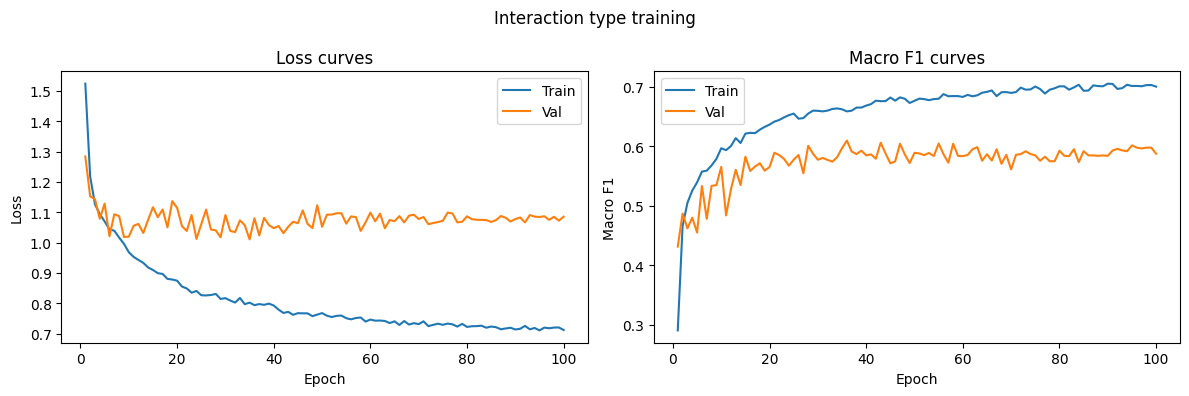

In [6]:
model = GCNClassifier(in_channels=2, hidden_dim=64,
                      num_classes=len(selected_interactions)).to(device)
int_criterion = torch.nn.CrossEntropyLoss(weight=int_weights.to(device))
model, int_history = train_model(model, int_criterion, 'y', 100, 'interaction')
torch.save(model.state_dict(), 'interaction_model.pt')
print("Saved interaction_model.pt")
plot_curves(int_history, 'Interaction type training', 'interaction_training_curves.pdf')


## Train biological class classifier

[bio_class] Epoch 010 | Train F1 0.738 loss 0.5131 | Val   F1 0.714 loss 0.4802
[bio_class] Epoch 020 | Train F1 0.772 loss 0.4676 | Val   F1 0.696 loss 0.5628
[bio_class] Epoch 030 | Train F1 0.789 loss 0.4345 | Val   F1 0.728 loss 0.5209
[bio_class] Epoch 040 | Train F1 0.795 loss 0.4158 | Val   F1 0.729 loss 0.5449
[bio_class] Epoch 050 | Train F1 0.797 loss 0.4068 | Val   F1 0.746 loss 0.5563
[bio_class] Epoch 060 | Train F1 0.804 loss 0.3981 | Val   F1 0.757 loss 0.5571
[bio_class] Epoch 070 | Train F1 0.805 loss 0.3904 | Val   F1 0.757 loss 0.5656
[bio_class] Epoch 080 | Train F1 0.812 loss 0.3846 | Val   F1 0.745 loss 0.5819
[bio_class] Epoch 090 | Train F1 0.810 loss 0.3800 | Val   F1 0.739 loss 0.5990
[bio_class] Epoch 100 | Train F1 0.814 loss 0.3810 | Val   F1 0.727 loss 0.5792
[bio_class] Best val macro F1: 0.7692
Saved bio_model.pt


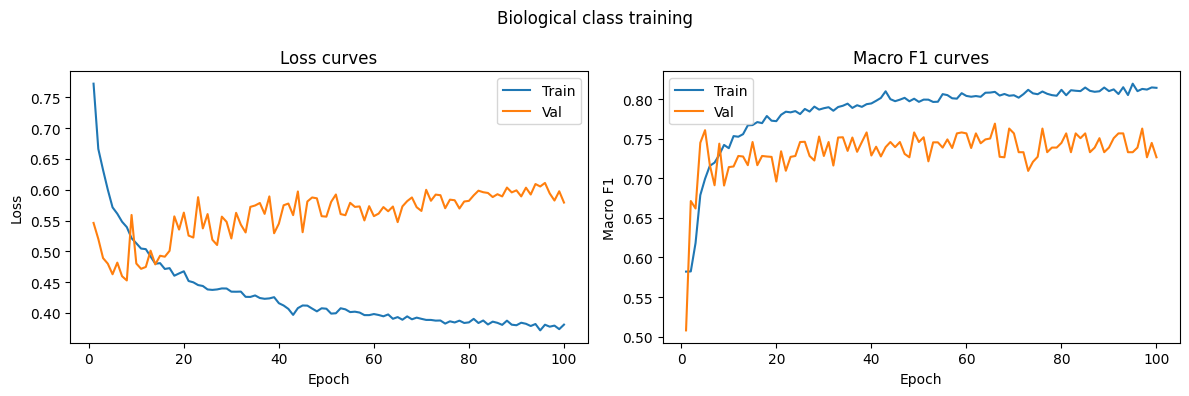

In [7]:
bio_model = GCNClassifier(in_channels=2, hidden_dim=64,
                          num_classes=len(selected_classes)).to(device)
bio_criterion = torch.nn.CrossEntropyLoss(weight=bio_weights.to(device))
bio_model, bio_history = train_model(bio_model, bio_criterion, 'bio_class', 100, 'bio_class')
torch.save(bio_model.state_dict(), 'bio_model.pt')
print("Saved bio_model.pt")
plot_curves(bio_history, 'Biological class training', 'bio_training_curves.pdf')
